In [1]:
pip install opencv-python "numpy<2" matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('/Users/230108/Downloads/imagee.png', cv2.IMREAD_GRAYSCALE)

# Task 1

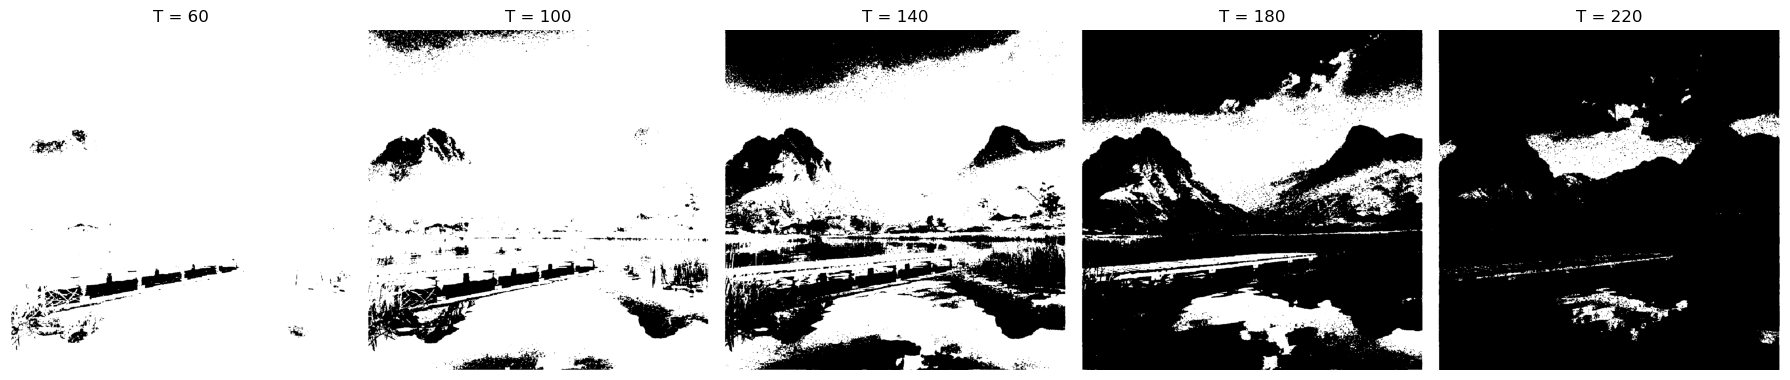

In [3]:
def global_threshold(image, T):
    return (image >= T).astype(np.uint8)
    
thresholds = [60, 100, 140, 180, 220]

fig, axes = plt.subplots(1, len(thresholds), figsize=(18,4))

for i, T in enumerate(thresholds):
    mask = global_threshold(image, T)
    axes[i].imshow(mask, cmap="gray")
    axes[i].set_title(f"T = {T}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


# Task 2

(-0.5, 1207.5, 1201.5, -0.5)

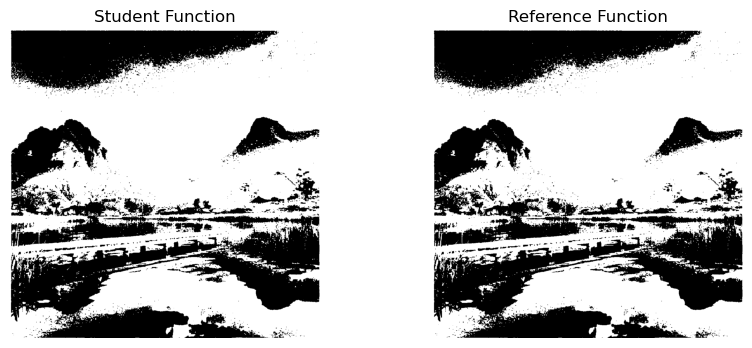

In [9]:
def my_threshold(image, T):
    rows, cols = image.shape
    output = np.zeros((rows, cols))

    for i in range(rows):
        for j in range(cols):
            if image[i, j] >= T:
                output[i, j] = 1
            else:
                output[i, j] = 0

    return output


T = 140
my_result = my_threshold(image, T)

# FIXED TYPO HERE ↓
_, cv_result = cv2.threshold(image, T, 1, cv2.THRESH_BINARY)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(my_result, cmap="gray")
plt.title("Student Function")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv_result, cmap="gray")
plt.title("Reference Function")
plt.axis('off')


# Task 3(challenge 1)

Automatic threshold: 151


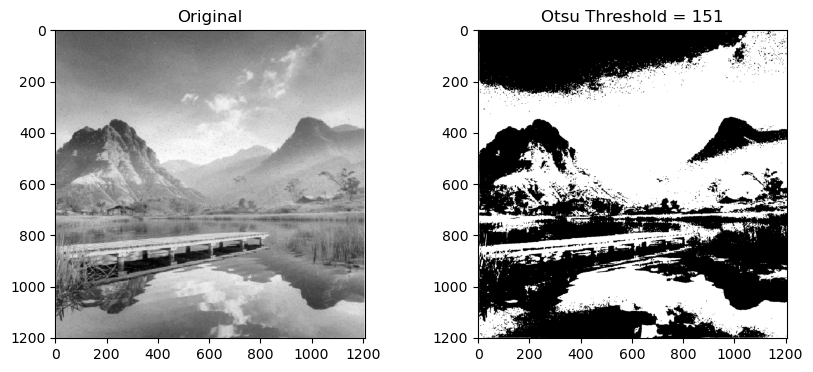

In [5]:
from skimage.filters import threshold_otsu

T_otsu = threshold_otsu(image)
print("Automatic threshold:", T_otsu)

mask_otsu = image >= T_otsu

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(mask_otsu, cmap="gray")
plt.title(f"Otsu Threshold = {T_otsu}")
plt.show()



# Challenge 2

In [11]:
mask_global = cv_result  

foreground_pixels = np.sum(mask_global)
total_pixels = mask_global.size
percentage = 100 * foreground_pixels / total_pixels

print("Foreground pixels:", foreground_pixels)
print("Percentage selected:", round(percentage, 2), "%")

Foreground pixels: 887950
Percentage selected: 61.15 %


# Challenge 3

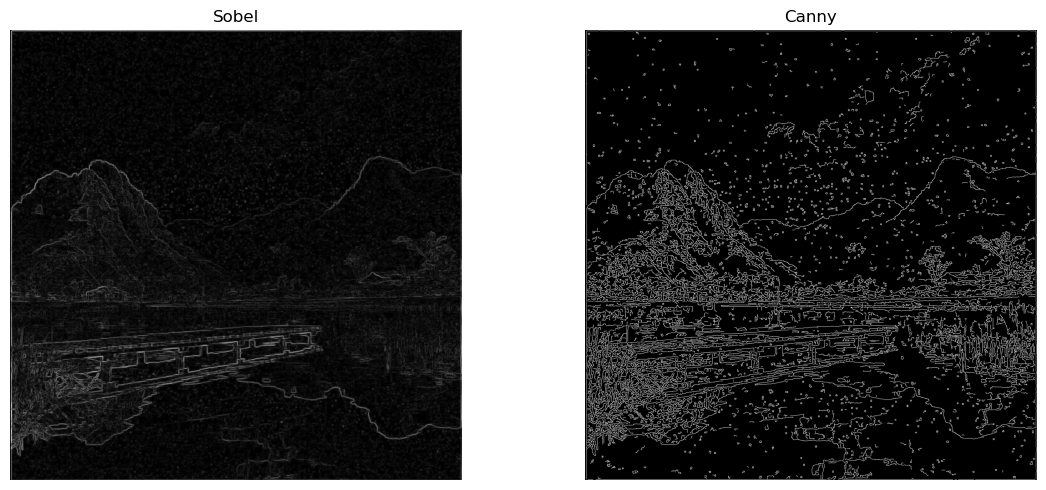

In [12]:
from skimage.filters import sobel
from skimage.feature import canny

edges_sobel = sobel(image)
edges_canny = canny(image / 255.0)

fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].imshow(edges_sobel, cmap="gray")
axes[0].set_title("Sobel")

axes[1].imshow(edges_canny, cmap="gray")
axes[1].set_title("Canny")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()